# Milestone 2: Threat Index Development

## 1. Design the Threat Index

We chose to do a application-specific impact, relating to good conditions for a beach day. Our target audience would be the general public, specifically beach goers. This can include tourists and people who live near a beach. 


### Threat Index: Perfect Beach Day Index

*Planning of index and graphs were completed by Hanna*
- Range: 0 to 10
- 0 = no beach day
- 10 = best possible
- I'll construct the index from 0-10

Best possible conditions:
- temperature bwteeen 75 - 85 F
- less than 75% cloud cover
- dew point between 55-75 F
- 0-25% cloud cloud coverage

Weighting: (note we changed temp from 30 to 65 and from precip from 40 to 25 wind from 15 to 7 and dew point from 10 to 2 clouds from 5 to 1 and  because the map wasn't looking right for the Low value day) 
- temperature: 65 % 
- precipation: 25 %
- wind: 7 %
- dew point: 2 %
- clouds: 1 %



Temperature contribution:
- 0 when T < 60 F
- 10 when 75 <= T <= 85
- 2.5 when T >= 100
- Linear slope from 60 - 75
- exponential decay from 85 - 100
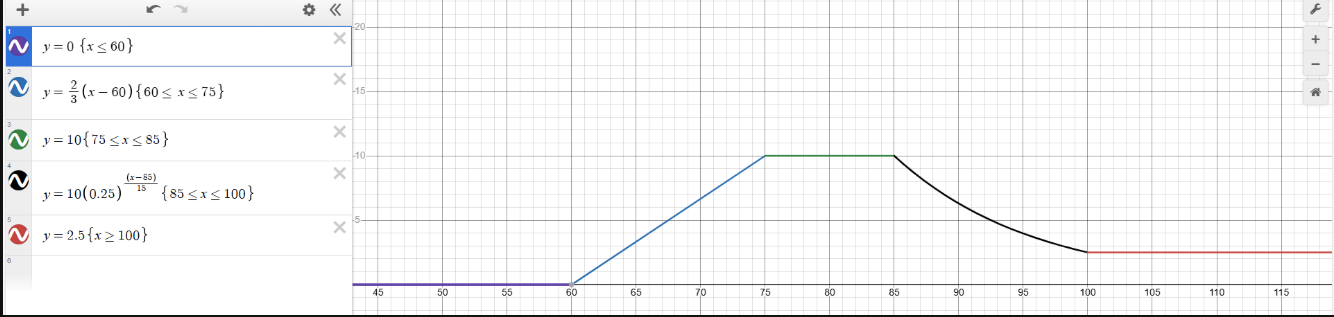


Precipation contribution: 
- 0 when forecast is >= 0.1 inches 
- 10 when forecast = 0
- negative slope between them between
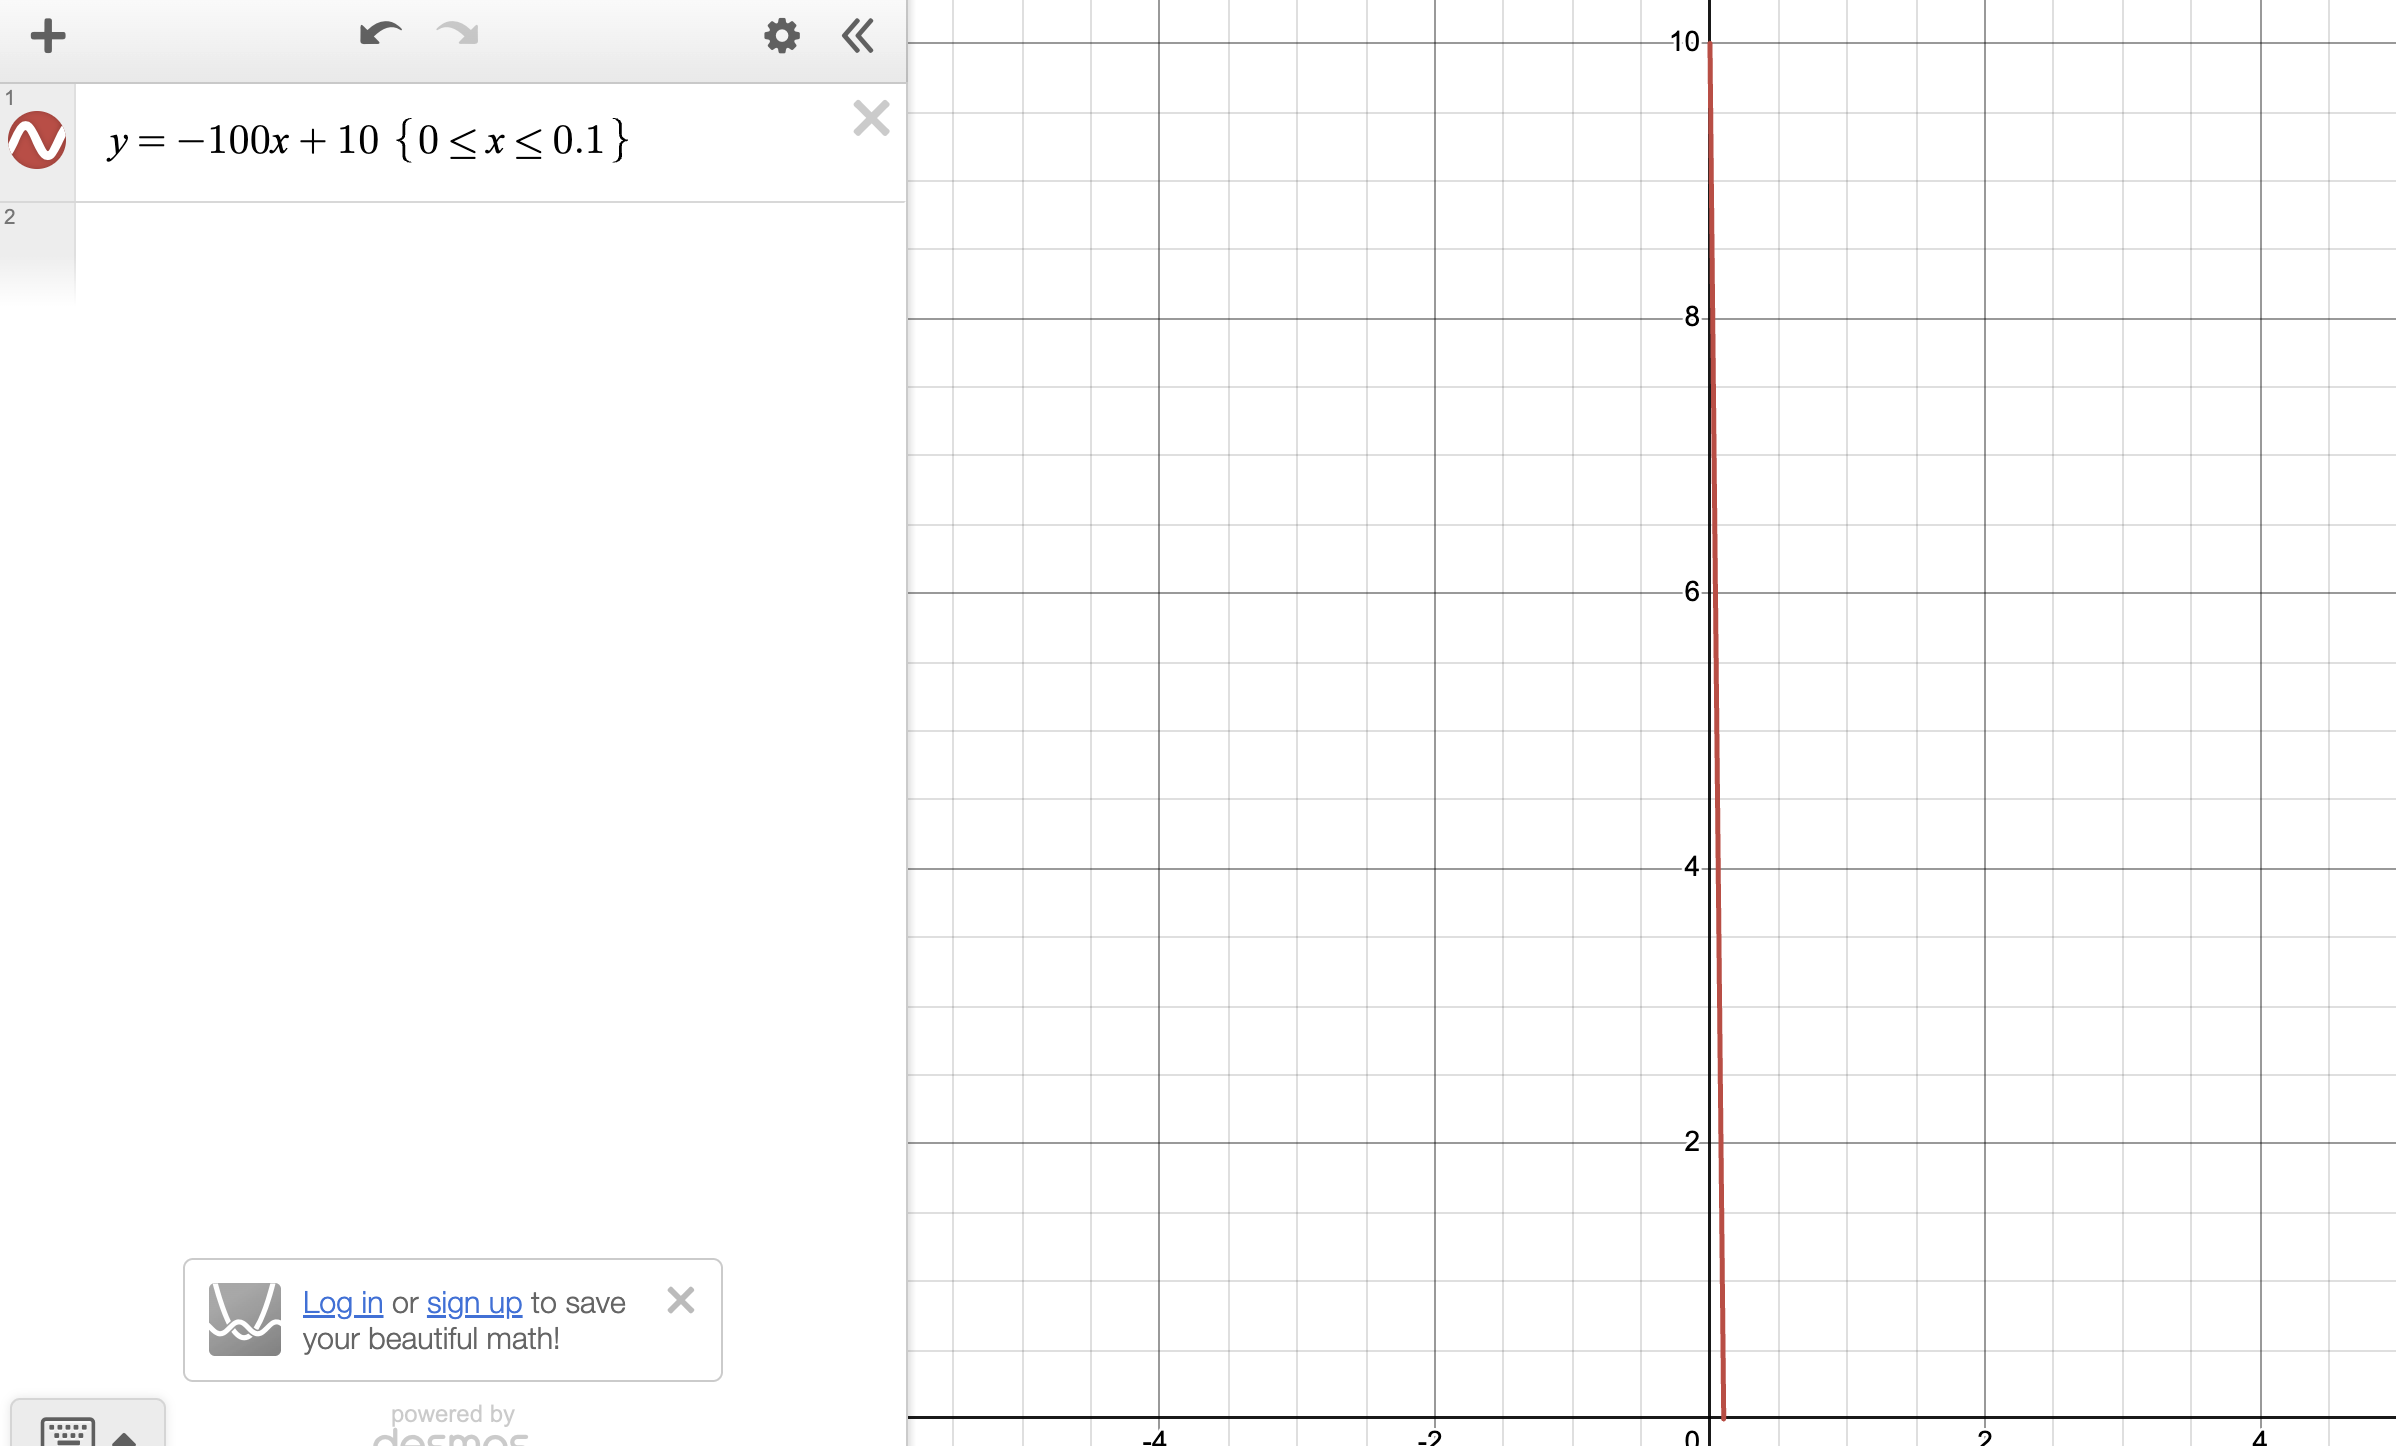

wind contribution:
- 0 when wind is over 2mph
- 10 when wind is under 10 mph
- exponential decay from 10 mph to 20 mph
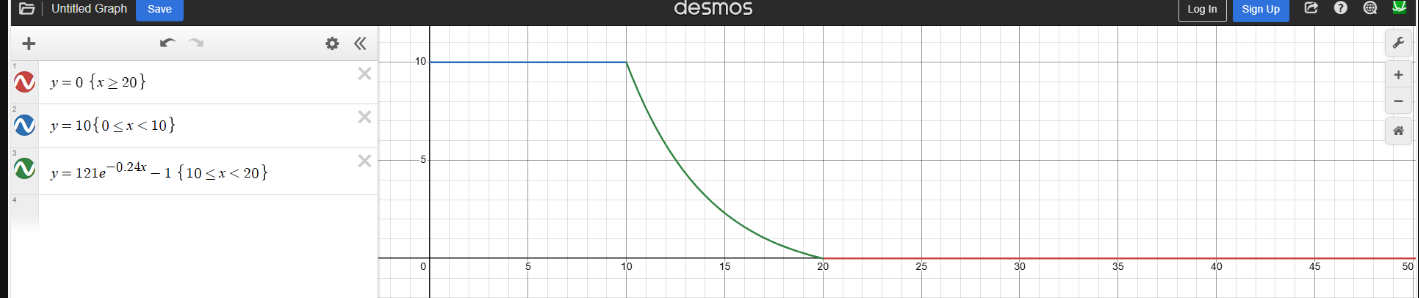

Dew Point contribution: 
- 10 for 55-75
- 0 for >=85
- 2.5 for <45
- exponental growth from 45 to 55 and exponentail decay from 75 to 85
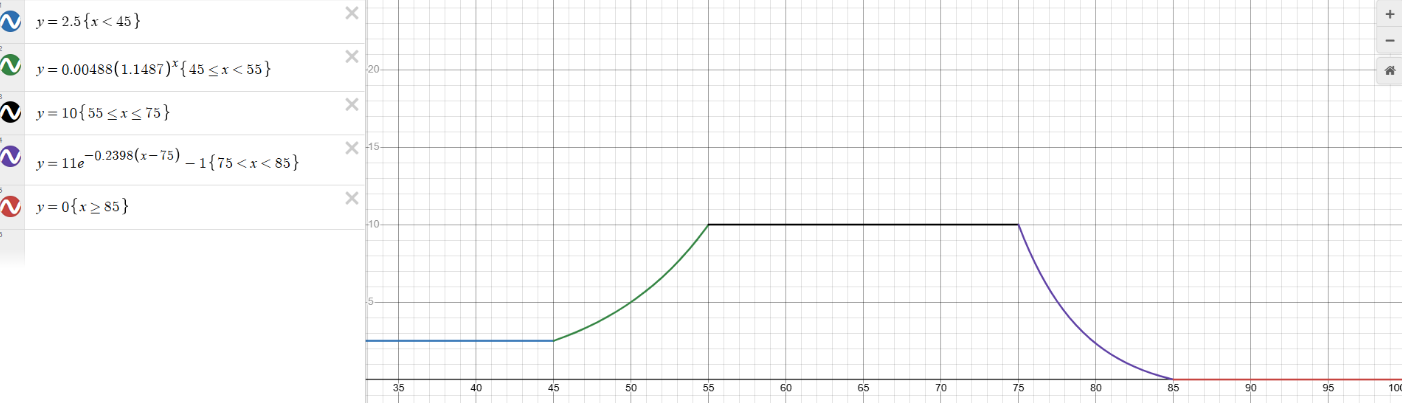

Cloud contribution:
- 0 when 80-100% 
- 10 for 0% to 35%
- with a straight line between the two
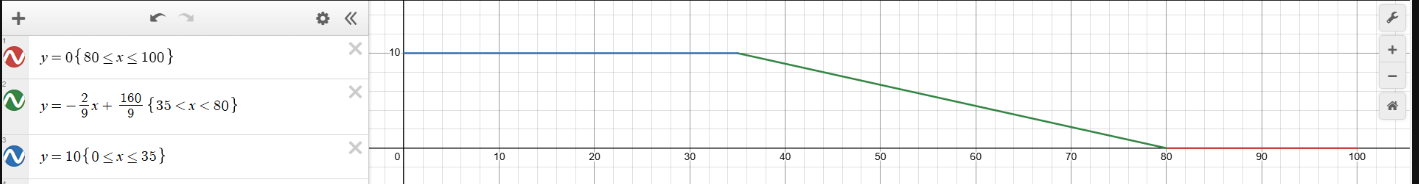

### Detailed Explanation
*Completed by Katie*

We chose the variables temperature, dewpoint, precipitation, cloud cover, and wind. We chose temperature and dew point to represent the comfort level of the temperature outside for beachgoers. With precipitation and cloud cover, it represents whether the weather is nice enough outside for people to sit at the beach. Wind speed was chosen because it can have an impact on objects used at the beach, such as umbrellas, surfing, parasailing, and other beach activities. The variable that has the most weight is temperature at 65%. This is because temperature would be the number one factor when deciding whether or not to go to the beach that day. Temperatures below a certain threshold would be too cold to sit at the beach, and temperatures above a certain threshold would have extreme heat risks. The variable with the second most weight is precipitation at 25% because precipitation rate would have a moderate effect on the conditions at the beach. Wind speeds holds a weight of 7%, since most breezy conditions are tolerable for beachgoers. Dew point and cloud cover are the least weighted variables for the index at 2% and 1%, since these two factors would have the least impact on the decision to go to the beach. For the index, we based it around a 1-10 scale, with 10 being the best conditions for a beach day. When creating the formula for the index, we incorporated the weights for each variable. 

For the temperature contribution in the index, we created our first range from 60 to 75, increasing linearly from 0 to 10. This is because as the temperature rises from 60 to 75, we are approaching peak conditions for our index. From 75 to 85, the line is constant at 10, because this is the peak condition for our index. Once it becomes greater than 85, the formula decreases exponentially to 100. This is because, as the temperature rises above 85, good conditions for the beach decrease as the risk for extreme heat becomes possible. At any value greater than 100, the formula holds steady at 2.5 because once temperatures are beyond 100 degrees, the heat risk is too high for good beach conditions. It is not totally zero because some may still choose to go to the beach in these conditions. For dewpoint contribution, the starting range was values less than 45, which were rated a 2.5. The function then exponentially increased from 45 to 55, representing the gradual climb to pleasant conditions. From 55 to 75, the line is constant at a value of 10, because these are the best conditions for our index. Starting at 75, it begins to decay exponentially down to 85, as dewpoint conditions become unpleasant. From 85 to any value larger, the index drops to 0, as these are bad conditions for the beach. For the precipitation contribution, the index starts at a perfect 10 when the rate of precipitation is 0 inches per hour, and linearly decreases down to 0 until 0.1 inches. For the wind contribution, the index begins at 10 for wind speeds from 0 to 20 miles per hour. It then decays exponentially until it reaches 20 miles per hour, where it remains at an index value of 0. The cloud cover contribution remains steady starting at 0% and ending at 35%, before it decreases linearly from 35% to 80% cloud cover.

This index is useful for our target audience because it can keep them informed about potential hazards that could impact their day at the beach. These hazards can include things such as excessive heat, heavy rain, and dangerous wind speeds. By having an overall index that tells them whether or not they should go to the beach, they can make an informed decision regarding whether or not to go.


### Develop and Test Formula

In [3]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

In [4]:
ds = xr.open_dataset('beachday_new.nc') #Opening our dataset saved in MS1
#The name changed from MS1 because we added the precipitation rate variable to the dataset

ds_time=ds.isel(valid_time=5) #Picking the hour that is being plotted

sh: 1: getfattr: not found


*Variable contribution calclulations were completed by Katie*

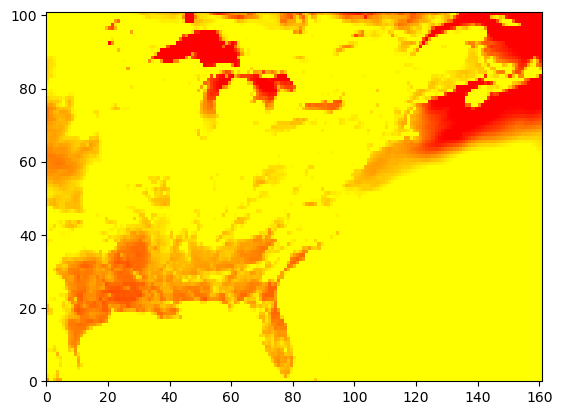

In [5]:
#Temperature index calculations
temp_f = (ds_time['t2m'].values - 273.15)*(9/5) + 32 #Conversion of temperature from Kelvin to Fahrenheit
temp_f.max()
temp_contribution = np.zeros_like(temp_f) #Creation of array of zeros

# T < 60 : Contribution= 0
mask = temp_f <=60
temp_contribution[mask] = 0

# 60 <= T < 75 : linear increase from 0 to 10
mask = (temp_f >= 60) & (temp_f < 75)
temp_contribution[mask] = (2/3)*(temp_f[mask] - 60)

# 75 <= T < 85 : Contribution= 10
mask = (temp_f >= 75) & (temp_f <= 85)
temp_contribution[mask] = 10.0

# 85 <= T < 100 : Exponential decay from 10 to 2.5
mask = (temp_f > 85) & (temp_f < 100)
temp_contribution[mask] = 10*(0.25)**((temp_f[mask]-85)/15) 

# 100 < T : Contribution= 2.5
mask = temp_f >= 100
temp_contribution[mask] = 2.5
plt.pcolormesh(np.flipud(temp_contribution), cmap='autumn') #Plot to check that the temperaure index works

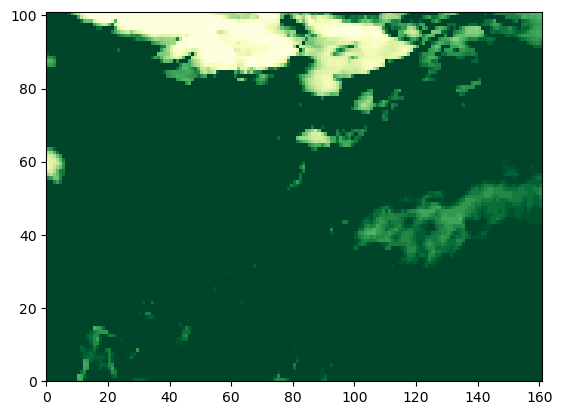

In [6]:
#Dew point index calculations
dewpoint_f = (ds_time['d2m'].values - 273.15)*(9/5) + 32 #Conversion of dew point values from Kelvin to Fahrenheit 
dewpoint_f.max() 

dewpoint_contribution = np.zeros_like(dewpoint_f) #Creation of array of zeros 

# DP < 45 : Contribution= 3.5
mask = (dewpoint_f<45)
dewpoint_contribution[mask]=2.5

# 45 <= DP < 55 : Exponential increase from 2.5 to 10
mask = (dewpoint_f >= 45) & (dewpoint_f < 55)
dewpoint_contribution[mask] = 0.004488*(1.1487)**(dewpoint_f[mask])

# 55 <= DP <= 75 : Contribution = 10 
mask = (dewpoint_f >= 55) & (dewpoint_f <= 75)
dewpoint_contribution[mask] = 10.0

# 75 < DP < 85 : Exponential decay from 10 to 0
mask = (dewpoint_f > 75) & (dewpoint_f < 85)
dewpoint_contribution[mask] = 11*np.exp(-0.2398*(dewpoint_f[mask]-75))-1

# 85 <= DP = : Contribution = 0
mask = dewpoint_f >= 85
dewpoint_contribution[mask] = 0

plt.pcolormesh(np.flipud(dewpoint_contribution), cmap='YlGn')  #Plot to check that the dew point index works

In [ ]:
# Total cloud cover index calculation
totalcloud = (ds_time['tcc'].values)
totalcloud.max() 

cloud_contribution = np.zeros_like(totalcloud) #Creation of array of zeros

# 0 <= TCC <+ 35 : Contribution= 10
mask = (totalcloud >= 0) & (totalcloud <= 35)
cloud_contribution[mask] = 10

# 35 < TCC < 80 : Exponential decay from 10 to 0
mask = (totalcloud > 35) & (totalcloud < 80)
cloud_contribution[mask] = ((-2/9)*(totalcloud[mask]))+(160/9)

# 80 <= TCC <= 100 : Contribution = 0
mask = (totalcloud >= 80) & (totalcloud <= 100)
cloud_contribution[mask] = 0

plt.pcolormesh(np.flipud(cloud_contribution), cmap='Blues') #Plot to check that the total cloud cover index works

In [ ]:
# Wind speed index calculation
u=(ds_time['u10'].values)
v=(ds_time['v10'].values)

wind= np.sqrt(u**2+v**2) #Calculation of the wind speed
wind_mph= wind*2.23693629 #Conversion from m/s to mph

wind_mph.max()

wind_contribution = np.zeros_like(wind_mph) #Creation of array of zeros

# 0 <= W < 10 : Contribution = 10
mask = (wind_mph >= 0) & (wind_mph < 10)
wind_contribution[mask] = 10

# 10 < W < 20 : Exponential decay from 10 to 0
mask = (wind_mph > 10) & (wind_mph < 20)
wind_contribution[mask] =121*np.exp(-0.24*(wind_mph[mask]))-1

# 20 <= W : Contribution = 0
mask = (wind_mph >= 20) 
wind_contribution[mask] = 0

plt.pcolormesh(np.flipud(wind_contribution), cmap='gray') #Plot to check that cloud cover index works

In [ ]:
# Precipitation rate index calculation 
prate_mm = ds_time['prate'].values
prate_mm_hr = prate_mm*3600 #Conversion from minutes to hour
prate_in_hr= prate_mm_hr*0.0393701 #Conversion from mm/hr to in/min 

prate_in_hr.max() 

precip_contribution = np.zeros_like(prate_in_hr) #Creation of array of zeros

# 0 <= PRATE <= 0.1 : Linear decrease from 10 to 0
mask = (prate_in_hr >= 0) & (prate_in_hr <= 0.1)
precip_contribution[mask] = (-50*(prate_in_hr[mask]))+10

plt.pcolormesh(np.flipud(precip_contribution), cmap='winter')

In [ ]:
#Calculation of total beach day index, including the weight of each variable
BD_index = (temp_contribution*0.3+dewpoint_contribution*.05+cloud_contribution*.10+wind_contribution*.15+precip_contribution*.40)*100
BD_index

## 2. Implement the Algorithm

In [ ]:
#Function defined for beach day index 
def beachday_index(ds,ts):
    ds_time=ds.isel(valid_time=ts)

    temp_f = (ds_time['t2m'].values - 273.15)*(9/5) + 32
    temp_contribution = np.zeros_like(temp_f)
    mask = temp_f <=60
    temp_contribution[mask] = 0
    mask = (temp_f >= 60) & (temp_f < 75)
    temp_contribution[mask] = (2/3)*(temp_f[mask] - 60)
    mask = (temp_f >= 75) & (temp_f <= 85)
    temp_contribution[mask] = 10.0
    mask = (temp_f > 85) & (temp_f < 100)
    temp_contribution[mask] = 10*(0.25)**((temp_f[mask]-85)/15) 
    mask = temp_f >= 100
    temp_contribution[mask] = 2.5

    dewpoint_f = (ds_time['d2m'].values - 273.15)*(9/5) + 32
    dewpoint_f.max() 
    dewpoint_contribution = np.zeros_like(dewpoint_f)
    mask = (dewpoint_f<45)
    dewpoint_contribution[mask]=2.5
    mask = (dewpoint_f >= 45) & (dewpoint_f < 55)
    dewpoint_contribution[mask] = 0.004488*(1.1487)**(dewpoint_f[mask])
    mask = (dewpoint_f >= 55) & (dewpoint_f <= 75)
    dewpoint_contribution[mask] = 10.0
    mask = (dewpoint_f > 75) & (dewpoint_f < 85)
    dewpoint_contribution[mask] = 11*np.exp(-0.2398*(dewpoint_f[mask]-75))-1
    mask = dewpoint_f >= 85
    dewpoint_contribution[mask] = 0

    totalcloud = (ds_time['tcc'].values)
    totalcloud.max() 
    cloud_contribution = np.zeros_like(totalcloud)
    mask = (totalcloud >= 0) & (totalcloud <= 35)
    cloud_contribution[mask] = 10
    mask = (totalcloud > 35) & (totalcloud < 80)
    cloud_contribution[mask] = ((-2/9)*(totalcloud[mask]))+(160/9)
    mask = (totalcloud >= 80) & (totalcloud <= 100)
    cloud_contribution[mask] = 0

    u=(ds_time['u10'].values)
    v=(ds_time['v10'].values)
    wind= np.sqrt(u**2+v**2)
    wind_mph= wind*2.23693629 
    wind_mph.max()
    wind_contribution = np.zeros_like(wind_mph)
    mask = (wind_mph >= 0) & (wind_mph < 10)
    wind_contribution[mask] = 10
    mask = (wind_mph > 10) & (wind_mph < 20)
    wind_contribution[mask] =121*np.exp(-0.24*(wind_mph[mask]))-1
    mask = (wind_mph >= 20) 
    wind_contribution[mask] = 0
    mask = wind_contribution < 0
    wind_contribution[mask] = 0

    prate_mm = ds_time['prate'].values
    prate_mm_hr = prate_mm*3600
    prate_in_hr = prate_mm_hr*0.0393701
    precip_contribution = np.zeros_like(prate_in_hr)
    mask = (prate_in_hr >= 0) & (prate_in_hr <= 0.1)
    precip_contribution[mask] = (-50*(prate_in_hr[mask]))+10

    BD_index = (temp_contribution*0.65+dewpoint_contribution*.02+cloud_contribution*.01+wind_contribution*.07+precip_contribution*.25)
    return BD_index, temp_contribution, dewpoint_contribution, cloud_contribution, wind_contribution, precip_contribution

## 3. Visualize the Outputs

*Six panel plot definition completed by Emma*

In [ ]:
#Define function
def six_plots(init_time, valid_time):
    #2-by-3 panel plot
    fig = plt.figure(figsize=(20, 20))
    ax_1 = fig.add_subplot(3, 2, 1, projection=ccrs.PlateCarree())
    ax_2 = fig.add_subplot(3, 2, 2, projection=ccrs.PlateCarree())
    ax_3 = fig.add_subplot(3, 2, 3, projection=ccrs.PlateCarree())
    ax_4 = fig.add_subplot(3, 2, 4, projection=ccrs.PlateCarree())
    ax_5 = fig.add_subplot(3, 2, 5, projection=ccrs.PlateCarree())
    ax_6 = fig.add_subplot(3, 2, 6, projection=ccrs.PlateCarree())
    fig.suptitle("Beach Day Index and Parameters", fontsize=20, y=1.183)

    #Set levels
    levels = np.arange(0, 10.25, 0.25)
    
    #Subplot 1: Precipitation
    ax_1.set_title("Precipitation Contribution to Overall Index", loc='left', fontsize=16)
    ax_1.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_1.add_feature(cfeature.COASTLINE)
    ax_1.add_feature(cfeature.BORDERS)
    ax_1.add_feature(cfeature.STATES)
    ax_1.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    precip_map = ax_1.contourf(ds['longitude'].values, ds['latitude'].values, precip, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 2: Temperature
    ax_2.set_title("Temperature Contribution to Overall Index", loc='left', fontsize=16)
    ax_2.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_2.add_feature(cfeature.COASTLINE)
    ax_2.add_feature(cfeature.BORDERS)
    ax_2.add_feature(cfeature.STATES)
    ax_2.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_2.contourf(ds['longitude'].values, ds['latitude'].values, temp, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 3: Wind
    ax_3.set_title("Wind Contribution to Overall Index", loc='left', fontsize=16)
    ax_3.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_3.add_feature(cfeature.COASTLINE)
    ax_3.add_feature(cfeature.BORDERS)
    ax_3.add_feature(cfeature.STATES)
    ax_3.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_3.contourf(ds['longitude'].values, ds['latitude'].values, wind, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 4: Cloud Cover
    ax_4.set_title("Cloud Cover Contribution to Overall Index", loc='left', fontsize=16)
    ax_4.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_4.add_feature(cfeature.COASTLINE)
    ax_4.add_feature(cfeature.BORDERS)
    ax_4.add_feature(cfeature.STATES)
    ax_4.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_4.contourf(ds['longitude'].values, ds['latitude'].values, cloud, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 5: Dewpoint
    ax_5.set_title("Dewpoint Contribution to Overall Index", loc='left', fontsize=16)
    ax_5.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_5.add_feature(cfeature.COASTLINE)
    ax_5.add_feature(cfeature.BORDERS)
    ax_5.add_feature(cfeature.STATES)
    ax_5.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_5.contourf(ds['longitude'].values, ds['latitude'].values, dewpoint, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 6: Overall Index
    ax_6.set_title("Total Beach Day Index", loc='left', fontsize=16)
    ax_6.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_6.add_feature(cfeature.COASTLINE)
    ax_6.add_feature(cfeature.BORDERS)
    ax_6.add_feature(cfeature.STATES)
    ax_6.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_6.contourf(ds['longitude'].values, ds['latitude'].values, bd, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Fix layout issues
    plt.tight_layout(rect=[0, 0.05, 1, 1.19])     #Reserves space for individual titles

    #Colorbar
    cbar = fig.colorbar(precip_map, ax=[ax_1, ax_2, ax_3, ax_4, ax_5, ax_6], orientation='horizontal', pad=0.03, fraction=0.0495)
    cbar.set_label("Contribution to Beach Day Index", fontsize=16)
    
    #Show figure
    plt.show()

### 6 Different Time Steps 

*All 6 time steps were completed by Hanna*

In [ ]:
timestep=1
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
six_plots(init_time, valid_time)

In [ ]:
timestep=5
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
six_plots(init_time, valid_time)

In [ ]:
timestep=9
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
six_plots(init_time, valid_time)

In [ ]:
timestep=13
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
six_plots(init_time, valid_time)

In [ ]:
timestep=17
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
six_plots(init_time, valid_time)

In [ ]:
timestep=21
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
six_plots(init_time, valid_time)

## 4. Test Algorithm on Additional Events

*High and Low index day plots completed by Hanna*

### Import of Low index day (DO NOT RUN)

In [ ]:
run= pd.Timestamp("2026-01-13-12") #Chosen date for low index day

In [ ]:
H = Herbie(run, model="gfs", fxx=12, save_dir='./data/', overwrite=True, source='ncei_analysis') #Finding dataset

In [ ]:
table= H.inventory() 

In [ ]:
table.variable.unique()

In [ ]:
H.inventory("PRATE")

In [ ]:
#Retrieval of variables
ss = r":((DPT|TMP):(2 m above ground))|(TCDC:entire atmosphere:\d+\s)" 
ss2 = r"((UGRD|VGRD):(10 m above ground))"
ss3 = r"(PRATE:surface:\d+ hour)"

H.inventory(ss3) 

In [ ]:
H = FastHerbie([run], model="gfs", fxx=np.arange(6,246,6).tolist(), save_dir='./data/', overwrite=True)

In [ ]:
fp = H.download(ss)
fp

fp2= H.download(ss2)
fp2

In [ ]:
fp3= H.download(ss3)
fp3

In [ ]:
# open all datasets
ds = xr.open_mfdataset(fp, combine='nested', concat_dim='valid_time', engine='cfgrib', coords='minimal', compat='override')
ds

ds2 = xr.open_mfdataset(fp2, combine='nested', concat_dim='valid_time', engine='cfgrib')
ds2

ds3 = xr.open_mfdataset(fp3, combine='nested', concat_dim='valid_time', engine='cfgrib')
ds3

ds4= xr.merge([ds,ds2,ds3], compat='override')
ds4

ds5 = ds4.sel(latitude=slice(50,25), longitude=slice(260,300))
ds5

In [ ]:
#Download as NetCDF
fname = f'bad_day.nc'
ds5.to_netcdf(fname)

### Import of High Index day (DO NOT RUN)

In [ ]:
run= pd.Timestamp("2025-05-14-12") # Date for high index day

In [ ]:
H = Herbie(run, model="gfs", fxx=12, save_dir='./data/', overwrite=True, source='ncei_analysis') #Finding dataset

In [ ]:
table= H.inventory() 

In [ ]:
table.variable.unique()

In [ ]:
H.inventory("PRATE")

In [ ]:
#Retrieval of variables
ss = r":((DPT|TMP):(2 m above ground))|(TCDC:entire atmosphere:\d+\s)" 
ss2 = r"((UGRD|VGRD):(10 m above ground))"
ss3 = r"(PRATE:surface:\d+ hour)"

H.inventory(ss3) 

In [ ]:
H = FastHerbie([run], model="gfs", fxx=np.arange(6,246,6).tolist(), save_dir='./data/', overwrite=True)

In [ ]:
fp = H.download(ss)
fp

fp2= H.download(ss2)
fp2

In [ ]:
fp3= H.download(ss3)
fp3

In [ ]:
#Open all datasets
ds = xr.open_mfdataset(fp, combine='nested', concat_dim='valid_time', engine='cfgrib', coords='minimal', compat='override')
ds

ds2 = xr.open_mfdataset(fp2, combine='nested', concat_dim='valid_time', engine='cfgrib')
ds2

ds3 = xr.open_mfdataset(fp3, combine='nested', concat_dim='valid_time', engine='cfgrib')
ds3

ds4= xr.merge([ds,ds2,ds3], compat='override')
ds4

ds5 = ds4.sel(latitude=slice(50,25), longitude=slice(260,300))
ds5

In [ ]:
#Download as NetCDF
fname = f'good_day.nc'
ds5.to_netcdf(fname)

### Plot of Low value Day

In [ ]:
ds = xr.open_dataset('bad_day.nc')
timestep=0
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
six_plots(init_time, valid_time)

### Plot of High Value Day

In [ ]:
ds = xr.open_dataset('good_day.nc')
timestep=0
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)
six_plots(init_time, valid_time)

### Evaluation of Algorithm Performance

To test our algorithm, we chose a good day in May and a bad day in January. Our algorithm produced reasonable values for both the good day and the bad day for our index. Our bad day produced low values for all of the parameters, which contributed to a map that showed low values for the total index. Our good day index was not as well produced as the bad day because we found it more difficult to find a dataset that is perfect. The good day data was not at a perfect 10 for the entirety of the east coast due to some areas being colder and rainier than others. Overall, the index did not miss any large scale events. We ended up changing our precipitation and temperature values. We increased the weight of our temperature value because on the bad day it was not producing as low of values as it should with the original weighting of the temperature variable. We decided to lower each variable in order greatly increase the weight of temperature.

## 5. Automate Plot Generation

*Plot generation completed by Emma*

In [ ]:
#Create plotting function for threat index only
def plot_index(ds, bd, timestep, init_time, valid_time, save=True):
    #Create plot and colorbar
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_title("Beach Day Index", loc='left', fontsize=12)
    ax.set_title(f'Init: {init_time}\nValid: {valid_time}', loc='right', fontsize=12)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    ax.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    levels = np.arange(0, 10.25, 0.25)
    final_index = ax.contourf(ds['longitude'].values, ds['latitude'].values, bd, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    index_cb = fig.colorbar(final_index, ax=ax, orientation='horizontal', pad=0.05)
    plt.tight_layout()

    #Save figure as .png file
    if save:
        file_name = f"final_index_{timestep:03d}.png"
        plt.savefig(file_name, dpi=150)
        plt.close(fig)
    else:
        plt.show()

In [ ]:
#Loop through all timesteps
for t in range(ds.dims['valid_time']):
    bd, temp, dewpoint, cloud, wind, precip = beachday_index(ds, t)
    valid_time = pd.to_datetime(ds.valid_time.values[t]).strftime('%HZ %b %d %Y')
    plot_index(ds, bd, t, init_time, valid_time)

## 6. Convert to Python Script

*Completed in Another File by Emma*